In [ ]:
# SETUP

import os

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats

# Use BatchTopKSAE from dictionary_learning library
from dictionary_learning.trainers.batch_top_k import BatchTopKSAE

# Import project utilities (add parent to path for imports)
import sys
sys.path.insert(0, '..')
from model_scripts.model_utils import configure_runtime, load_model, parse_model_name_safe
from model_scripts.data import get_dataset

# Set Device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")
torch.set_grad_enabled(False) # don't need gradients - analysis only

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Configuration (Must match training) ---
MODEL_NAME = '2layer_100dig_64d'
MODEL_CFG = parse_model_name_safe(MODEL_NAME)
SAVE_FOLDER = '../results/sae_models'

SAVE_NAME = 'sae_d100_k4_50ksteps_2layer_100dig_64d.pt'
SAE_PATH = os.path.join(SAVE_FOLDER, SAVE_NAME)

# from model
D_MODEL = MODEL_CFG.d_model
N_LAYERS = MODEL_CFG.n_layers
N_HEADS = 1
LIST_LEN = 2
N_DIGITS = MODEL_CFG.n_digits
SEP_TOKEN_INDEX = 2  # Position of SEP in [d1, d2, SEP, o1, o2]

# Output Config
SAVE_RESULTS = False
if SAVE_RESULTS:
    SAVE_DIR = "../results/sae_results/"
else:
    SAVE_DIR = None

# --- Load Models ---
MODEL_PATH = "../models/" + MODEL_NAME + ".pt"

# Setup Runtime (required by model_utils)
configure_runtime(
    list_len=LIST_LEN,
    seq_len=2 * LIST_LEN + 1,  # [d1, d2, SEP, o1, o2] = 5
    vocab=N_DIGITS + 2,  # digits + MASK + SEP
    device=device
)

# Load base transformer model (with required kwargs)
try:
    model = load_model(
        MODEL_PATH,
        n_layers=N_LAYERS,
        n_heads=N_HEADS,
        d_model=D_MODEL,
        ln=False,
        use_bias=False,
        use_wv=False,
        use_wo=False
    )
    print(f"✓ Loaded base model from {MODEL_PATH}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise

# Load SAE using library's BatchTopKSAE
sae_checkpoint = torch.load(SAE_PATH, map_location=device, weights_only=False)

# Extract config from checkpoint
sae_cfg = sae_checkpoint.get("cfg", {})
D_SAE = sae_cfg.get("dict_size", sae_cfg.get("d_sae", 256))
TOP_K = sae_cfg.get("k", 4)

# Library's BatchTopKSAE uses (activation_dim, dict_size, k) constructor
sae = BatchTopKSAE(
    activation_dim=D_MODEL,
    dict_size=D_SAE,
    k=TOP_K
).to(device)

# Load state dict (handles both old and new formats)
old_state_dict = sae_checkpoint["state_dict"]
if "W_enc" in old_state_dict:
    # Legacy format conversion (for old sae.pt)
    new_state_dict = {
        "encoder.weight": old_state_dict["W_enc"].T,
        "encoder.bias": old_state_dict["b_enc"],
        "decoder.weight": old_state_dict["W_dec"].T,
        "b_dec": old_state_dict["b_dec"],
    }
    sae.load_state_dict(new_state_dict, strict=False)
    print("  (Converted legacy checkpoint format)")
else:
    sae.load_state_dict(old_state_dict)
    print(f"  (Threshold: {sae.threshold.item():.4f})")

# Load the mean for centering (critical for SAE)
act_mean = sae_checkpoint["act_mean"].to(device)

print(f"✓ Loaded SAE from {SAE_PATH}")
print(f"  - Latent dim: {D_SAE}")
print(f"  - TopK: {TOP_K}")

Using device: mps
Parsed model config: 2 layers, 100 digits, 64 d_model
Loading model from ../models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded base model from ../models/2layer_100dig_64d.pt
  (Threshold: 0.1891)
✓ Loaded SAE from ../results/sae_models/sae_d100_k4_50ksteps_2layer_100dig_64d.pt
  - Latent dim: 100
  - TopK: 4


In [ ]:
# get sep acts
# Generate ALL (d1, d2) pairs for complete analysis
val_ds, _ = get_dataset(
    list_len=LIST_LEN,
    n_digits=N_DIGITS,
    train_split=1.0,  # Get all data
    no_dupes=False    # Include d1 == d2 cases
)
val_dl = DataLoader(val_ds, batch_size=2048, shuffle=False)

# Storage
all_d1 = []
all_d2 = []
all_sep_acts = []       # SEP token activations
all_sae_acts = []       # SAE latent activations
all_alpha_d1 = []       # Attention: SEP -> d1
all_alpha_d2 = []       # Attention: SEP -> d2

print("Collecting activations and attention patterns...")

layer_idx = 0  # Layer 1 (0-indexed) - where composition happens
hook_name_resid = f"blocks.{layer_idx}.hook_resid_post"
hook_name_attn = f"blocks.{layer_idx}.attn.hook_pattern"

def make_sae_patch_hook(sae_recon, sep_idx):
    """Hook that replaces SEP token residual with SAE reconstruction."""
    def hook(resid, hook):
        resid = resid.clone()
        resid[:, sep_idx, :] = sae_recon + act_mean.to(resid.device)
        return resid
    return hook

with torch.no_grad():
    for inputs, targets in tqdm(val_dl):
        inputs = inputs.to(device)
        
        # Extract d1, d2 values
        d1 = inputs[:, 0]
        d2 = inputs[:, 1]
        
        # Run model and cache activations
        _, cache = model.run_with_cache(
            inputs, 
            stop_at_layer=layer_idx + 1,
            names_filter=[hook_name_resid, hook_name_attn]
        )
        
        # Get SEP token activations: [batch, d_model]
        sep_acts = cache[hook_name_resid][:, SEP_TOKEN_INDEX, :]
        
        # Get attention pattern: [batch, n_heads, seq, seq]
        # We want attention FROM SEP (query) TO d1 and d2 (keys)
        attn_pattern = cache[hook_name_attn][:, 0, :, :]  # [batch, seq, seq] (single head)
        alpha_d1 = attn_pattern[:, SEP_TOKEN_INDEX, 0]  # SEP attending to d1
        alpha_d2 = attn_pattern[:, SEP_TOKEN_INDEX, 1]  # SEP attending to d2
        
        # Run SAE encoding (with mean centering)
        sep_acts_centered = sep_acts - act_mean
        sae_z = sae.encode(sep_acts_centered, use_threshold=True)
        
        # Store
        all_d1.append(d1.cpu())
        all_d2.append(d2.cpu())
        all_sep_acts.append(sep_acts.cpu())
        all_sae_acts.append(sae_z.cpu())
        all_alpha_d1.append(alpha_d1.cpu())
        all_alpha_d2.append(alpha_d2.cpu())

# Concatenate
d1_all = torch.cat(all_d1)
d2_all = torch.cat(all_d2)
sep_acts_all = torch.cat(all_sep_acts)
sae_acts_all = torch.cat(all_sae_acts)
alpha_d1_all = torch.cat(all_alpha_d1)
alpha_d2_all = torch.cat(all_alpha_d2)

n_samples = len(d1_all)
print(f"\n✓ Collected {n_samples} samples")
print(f"  - SEP activations shape: {sep_acts_all.shape}")
print(f"  - SAE activations shape: {sae_acts_all.shape}")

100%|██████████| 5/5 [00:00<00:00, 45.14it/s]


✓ Collected 10000 samples
  - SEP activations shape: torch.Size([10000, 64])
  - SAE activations shape: torch.Size([10000, 100])


In [ ]:
# basic metrics

# L0 Sparsity
l0 = (sae_acts_all > 0).float().sum(dim=1).mean()
print(f"Average L0 (active features per sample): {l0:.2f}")

# Dead features
dead_features = (sae_acts_all.sum(dim=0) == 0).sum().item()
print(f"Dead features: {dead_features} / {D_SAE} ({100*dead_features/D_SAE:.1f}%)")

# Feature firing rates
firing_rate = (sae_acts_all > 0).float().mean(dim=0)
print(f"Firing rate range: [{firing_rate[firing_rate > 0].min():.4f}, {firing_rate.max():.4f}]")

Average L0 (active features per sample): 3.89
Dead features: 0 / 100 (0.0%)
Firing rate range: [0.0199, 0.4818]


 L0 ~= 4 is good
 no dead features!
 firing rate is ... meh?

In [ ]:
# max activating examples

# Analyze top features by firing rate
top_k_to_analyze = 10
top_feat_indices = torch.argsort(firing_rate, descending=True)[:top_k_to_analyze]

print(f"\nFor each of the top {top_k_to_analyze} features (by firing rate),")
print("showing the 5 inputs with highest activation:\n")

for rank, feat_idx in enumerate(top_feat_indices):
    feat_idx = feat_idx.item()
    feat_acts = sae_acts_all[:, feat_idx]
    
    if feat_acts.sum() == 0:
        continue
    
    # Get top 5 activating examples
    top5_indices = torch.argsort(feat_acts, descending=True)[:5]
    top5_acts = feat_acts[top5_indices]
    top5_d1 = d1_all[top5_indices]
    top5_d2 = d2_all[top5_indices]
    top5_alpha_d1 = alpha_d1_all[top5_indices]
    top5_alpha_d2 = alpha_d2_all[top5_indices]
    
    # Compute what digit/position this feature is most selective for
    d1_selectivity = torch.zeros(N_DIGITS)
    d2_selectivity = torch.zeros(N_DIGITS)
    for digit in range(N_DIGITS):
        d1_mask = (d1_all == digit)
        d2_mask = (d2_all == digit)
        if d1_mask.sum() > 0:
            d1_selectivity[digit] = feat_acts[d1_mask].mean()
        if d2_mask.sum() > 0:
            d2_selectivity[digit] = feat_acts[d2_mask].mean()
    
    best_d1_digit = d1_selectivity.argmax().item()
    best_d2_digit = d2_selectivity.argmax().item()
    is_d1_selective = d1_selectivity.max() > d2_selectivity.max()
    
    # Classify feature type
    alpha_diff_corr = np.corrcoef(feat_acts.numpy(), (alpha_d1_all - alpha_d2_all).numpy())[0, 1]
    
    if abs(alpha_diff_corr) > 0.5:
        feat_type = f"ORDER FEATURE? (r={alpha_diff_corr:.2f} with α_d1-α_d2)"
    elif is_d1_selective:
        feat_type = f"D1-Position: digit {best_d1_digit}"
    else:
        feat_type = f"D2-Position: digit {best_d2_digit}"
    
    print(f"{'─' * 55}")
    print(f"Feature {feat_idx} (rank #{rank+1}) — {feat_type}")
    print(f"{'─' * 55}")
    print(f"  {'d1':>4} {'d2':>4} {'α_d1':>6} {'α_d2':>6} {'Act':>8}")
    
    for i in range(5):
        print(f"  {top5_d1[i].item():>4} {top5_d2[i].item():>4} "
              f"{top5_alpha_d1[i].item():>6.3f} {top5_alpha_d2[i].item():>6.3f} "
              f"{top5_acts[i].item():>8.3f}")
    
    # Position invariance check (per colleague's suggestion)
    if not abs(alpha_diff_corr) > 0.5:  # Only check for digit-encoding features
        # Does this digit appear in both positions in the top activations?
        target_digit = best_d1_digit if is_d1_selective else best_d2_digit
        in_d1 = (top5_d1 == target_digit).sum().item()
        in_d2 = (top5_d2 == target_digit).sum().item()
        print(f"  → Target digit {target_digit} appears: {in_d1}x in d1, {in_d2}x in d2")
        
        # if is_d1_selective and in_d1 >= 4:
        #     print(f"  ✓ Position-specific (D1): Consistent with paper's prediction")
        # elif not is_d1_selective and in_d2 >= 4:
        #     print(f"  ✓ Position-specific (D2): Consistent with paper's prediction")
        # else:
        #     print(f"  ⚠ Mixed positions: May be polysemantic")
    
    print()


For each of the top 10 features (by firing rate),
showing the 5 inputs with highest activation:

───────────────────────────────────────────────────────
Feature 10 (rank #1) — ORDER FEATURE? (r=0.80 with α_d1-α_d2)
───────────────────────────────────────────────────────
    d1   d2   α_d1   α_d2      Act
    50   70  0.848  0.152    5.928
    10   70  0.889  0.111    5.648
    49   70  0.834  0.166    5.532
    46   70  0.831  0.169    5.476
    24   70  0.895  0.105    5.409

───────────────────────────────────────────────────────
Feature 84 (rank #2) — ORDER FEATURE? (r=-0.72 with α_d1-α_d2)
───────────────────────────────────────────────────────
    d1   d2   α_d1   α_d2      Act
    77    1  0.393  0.607    4.156
    77   29  0.172  0.828    4.022
    77   95  0.189  0.811    3.998
    77   39  0.326  0.674    3.976
    70    1  0.292  0.708    3.959

───────────────────────────────────────────────────────
Feature 25 (rank #3) — D1-Position: digit 53
──────────────────────────────

 okay lets focus on features 10 and 84, which activate a lot and highly correlate with the
 difference between attention sep-d1 and attn sep-d2 (i.e. could be an order feature)

In [ ]:
# Get embedding matrices from base model
w_e = model.embed.W_E.detach()  # [vocab, d_model] - token embeddings
w_pos = model.pos_embed.W_pos.detach()  # [seq_len, d_model] - position embeddings

# Compute D1 and D2 directions for all possible digit values
# D_i = E[d_i] + P[position_i]
# Position 0 = d1, Position 1 = d2
D1_directions = w_e[:N_DIGITS] + w_pos[0]  # [100, d_model]
D2_directions = w_e[:N_DIGITS] + w_pos[1]  # [100, d_model]

# Normalize decoder vectors for cosine similarity
W_dec = sae.decoder.weight.T.detach()  # [d_sae, d_model]
W_dec_norm = F.normalize(W_dec, dim=1)  # [d_sae, d_model]
D1_norm = F.normalize(D1_directions, dim=1)  # [100, d_model]
D2_norm = F.normalize(D2_directions, dim=1)  # [100, d_model]

# Compute max cosine similarity for each SAE feature
# For each decoder direction, find best matching D1 or D2 direction
cos_D1 = W_dec_norm @ D1_norm.T  # [d_sae, 100]
cos_D2 = W_dec_norm @ D2_norm.T  # [d_sae, 100]

max_cos_D1 = cos_D1.abs().max(dim=1).values  # [d_sae]
max_cos_D2 = cos_D2.abs().max(dim=1).values  # [d_sae]

# Get best match overall
best_match = torch.maximum(max_cos_D1, max_cos_D2)

# Analyze top features by firing rate
top_k_features = D_SAE # use all
top_indices = torch.argsort(firing_rate, descending=True)[:top_k_features]
top_alignments = best_match[top_indices]

print(f"\nAlignment of top {top_k_features} features (by firing rate) with D = E + P directions:")
print(f"  Mean cosine similarity: {top_alignments.mean():.4f}")
print(f"  Max cosine similarity:  {top_alignments.max():.4f}")
print(f"  Features with alignment > 0.8: {(top_alignments > 0.8).sum().item()}")
print(f"  Features with alignment > 0.5: {(top_alignments > 0.5).sum().item()}")


Alignment of top 100 features (by firing rate) with D = E + P directions:
  Mean cosine similarity: 0.8282
  Max cosine similarity:  0.9652
  Features with alignment > 0.8: 85
  Features with alignment > 0.5: 99


In [ ]:
# Find the feature with LOWEST alignment (not lowest firing rate)

# Exclude dead features (zero firing rate)
alive_mask = firing_rate > 0
alive_indices = torch.where(alive_mask)[0]
alive_alignments = best_match[alive_indices]

# Find minimum alignment among alive features
min_align_idx = alive_alignments.argmin()
lowest_align_feature = alive_indices[min_align_idx].item()
lowest_align_value = alive_alignments[min_align_idx].item()

print(f"Feature with lowest D1/D2 alignment: {lowest_align_feature}")
print(f"  Alignment: {lowest_align_value:.4f}")
print(f"  Firing rate: {firing_rate[lowest_align_feature]:.4f}")

# Show bottom 10 by alignment
sorted_by_align = torch.argsort(best_match)
print(f"\nBottom 10 features by alignment (excluding dead):")
count = 0
for idx in sorted_by_align:
    if firing_rate[idx] > 0:
        print(f"  Feature {idx.item()}: align={best_match[idx]:.4f}, fire_rate={firing_rate[idx]:.4f}")
        count += 1
        if count >= 10:
            break

Feature with lowest D1/D2 alignment: 86
  Alignment: 0.3748
  Firing rate: 0.0525

Bottom 10 features by alignment (excluding dead):
  Feature 86: align=0.3748, fire_rate=0.0525
  Feature 19: align=0.5338, fire_rate=0.0616
  Feature 14: align=0.5625, fire_rate=0.0562
  Feature 6: align=0.6055, fire_rate=0.0500
  Feature 29: align=0.6740, fire_rate=0.0240
  Feature 12: align=0.6754, fire_rate=0.0405
  Feature 41: align=0.6920, fire_rate=0.0251
  Feature 53: align=0.7571, fire_rate=0.0465
  Feature 7: align=0.7680, fire_rate=0.0199
  Feature 55: align=0.7728, fire_rate=0.0229


 it's 86 with 0.3748 alignment with D1/D2

Feature 10 Analysis (Lowest D1/D2 Alignment)

📊 Basic Stats:
  - Fires on 4818/10000 samples (48.18%)
  - Mean activation (when active): 1.7872
  - Alignment with best D1: 0.8732
  - Alignment with best D2: 0.3881

🔗 Order Feature Check:
  - r(feat, α_d1-α_d2): +0.8031
  → Likely an ORDER FEATURE!

🔢 Input Value Correlations:
  - r(feat, d1): +0.0108
  - r(feat, d2): -0.0123

🧭 Positional Alignment:
  - cos(feat, P[d1]-P[d2]): +0.9996


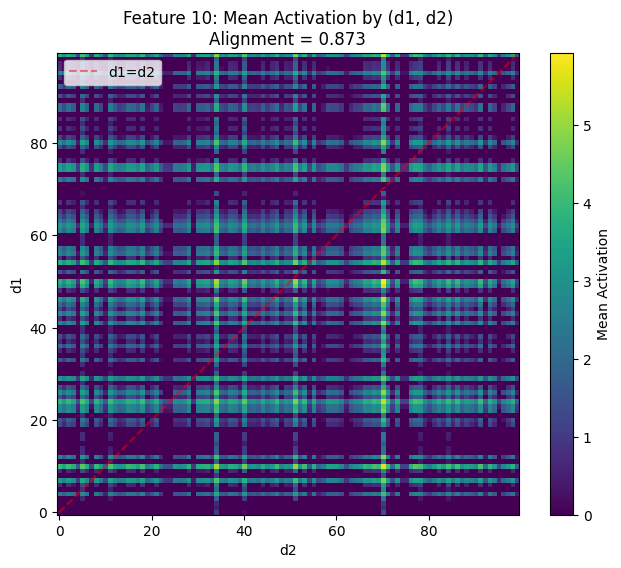


🔝 Top 10 Activating Examples:
    d1   d2    α_d1    α_d2      Δα      Act
    50   70   0.848   0.152  +0.697 5.928
    10   70   0.889   0.111  +0.779 5.648
    49   70   0.834   0.166  +0.668 5.532
    46   70   0.831   0.169  +0.661 5.476
    24   70   0.895   0.105  +0.791 5.409
    99   70   0.883   0.117  +0.767 5.388
    54   70   0.884   0.116  +0.769 5.365
    50   34   0.750   0.250  +0.500 5.147
    10   34   0.812   0.188  +0.623 5.084
    50   51   0.806   0.194  +0.612 5.005


In [ ]:
# Deep dive into feature 86 — lowest alignment with D1/D2 directions
# 84 and 10 have crazy patterns (86 wasnt that interesting)

FEATURE_IDX = 10 
feat_acts = sae_acts_all[:, FEATURE_IDX]

print(f"Feature {FEATURE_IDX} Analysis (Lowest D1/D2 Alignment)")
print("=" * 60)

# Basic stats
firing_mask = feat_acts > 0
n_firing = firing_mask.sum().item()
print(f"\n📊 Basic Stats:")
print(f"  - Fires on {n_firing}/{n_samples} samples ({100*n_firing/n_samples:.2f}%)")
print(f"  - Mean activation (when active): {feat_acts[firing_mask].mean():.4f}")
print(f"  - Alignment with best D1: {max_cos_D1[FEATURE_IDX]:.4f}")
print(f"  - Alignment with best D2: {max_cos_D2[FEATURE_IDX]:.4f}")

# Correlation with attention patterns (order feature?)
alpha_diff = alpha_d1_all - alpha_d2_all
corr_alpha_diff = np.corrcoef(feat_acts.numpy(), alpha_diff.numpy())[0, 1]
print(f"\n🔗 Order Feature Check:")
print(f"  - r(feat, α_d1-α_d2): {corr_alpha_diff:+.4f}")

if abs(corr_alpha_diff) > 0.5:
    print(f"  → Likely an ORDER FEATURE!")
else:
    print(f"  → Not strongly correlated with attention difference")

# Correlations with input values
corr_d1 = np.corrcoef(feat_acts.numpy(), d1_all.float().numpy())[0, 1]
corr_d2 = np.corrcoef(feat_acts.numpy(), d2_all.float().numpy())[0, 1]
print(f"\n🔢 Input Value Correlations:")
print(f"  - r(feat, d1): {corr_d1:+.4f}")
print(f"  - r(feat, d2): {corr_d2:+.4f}")

# Check pure positional alignment
pos_d1 = w_pos[0]
pos_d2 = w_pos[1]
pos_diff = pos_d1 - pos_d2
W_dec_feat = W_dec[FEATURE_IDX]

cos_pos_diff = F.cosine_similarity(W_dec_feat.unsqueeze(0), pos_diff.unsqueeze(0)).item()
print(f"\n🧭 Positional Alignment:")
print(f"  - cos(feat, P[d1]-P[d2]): {cos_pos_diff:+.4f}")

# Heatmap
act_matrix = torch.zeros(N_DIGITS, N_DIGITS)
count_matrix = torch.zeros(N_DIGITS, N_DIGITS)
for i in range(n_samples):
    act_matrix[d1_all[i], d2_all[i]] += feat_acts[i].item()
    count_matrix[d1_all[i], d2_all[i]] += 1
act_matrix = act_matrix / count_matrix.clamp(min=1)

plt.figure(figsize=(8, 6))
plt.imshow(act_matrix.numpy(), cmap='viridis', origin='lower')
plt.colorbar(label='Mean Activation')
plt.xlabel('d2')
plt.ylabel('d1')
plt.title(f'Feature {FEATURE_IDX}: Mean Activation by (d1, d2)\nAlignment = {best_match[FEATURE_IDX]:.3f}')
plt.plot([0, N_DIGITS-1], [0, N_DIGITS-1], 'r--', alpha=0.5, label='d1=d2')
plt.legend()
plt.show()

# Top activating examples
print(f"\n🔝 Top 10 Activating Examples:")
top10_idx = torch.argsort(feat_acts, descending=True)[:10]
print(f"  {'d1':>4} {'d2':>4} {'α_d1':>7} {'α_d2':>7} {'Δα':>7} {'Act':>8}")
for idx in top10_idx:
    d1, d2 = d1_all[idx].item(), d2_all[idx].item()
    ad1, ad2 = alpha_d1_all[idx].item(), alpha_d2_all[idx].item()
    print(f"  {d1:>4} {d2:>4} {ad1:>7.3f} {ad2:>7.3f} {ad1-ad2:>+7.3f} {feat_acts[idx]:.3f}")

Computing activation matrices for all features...


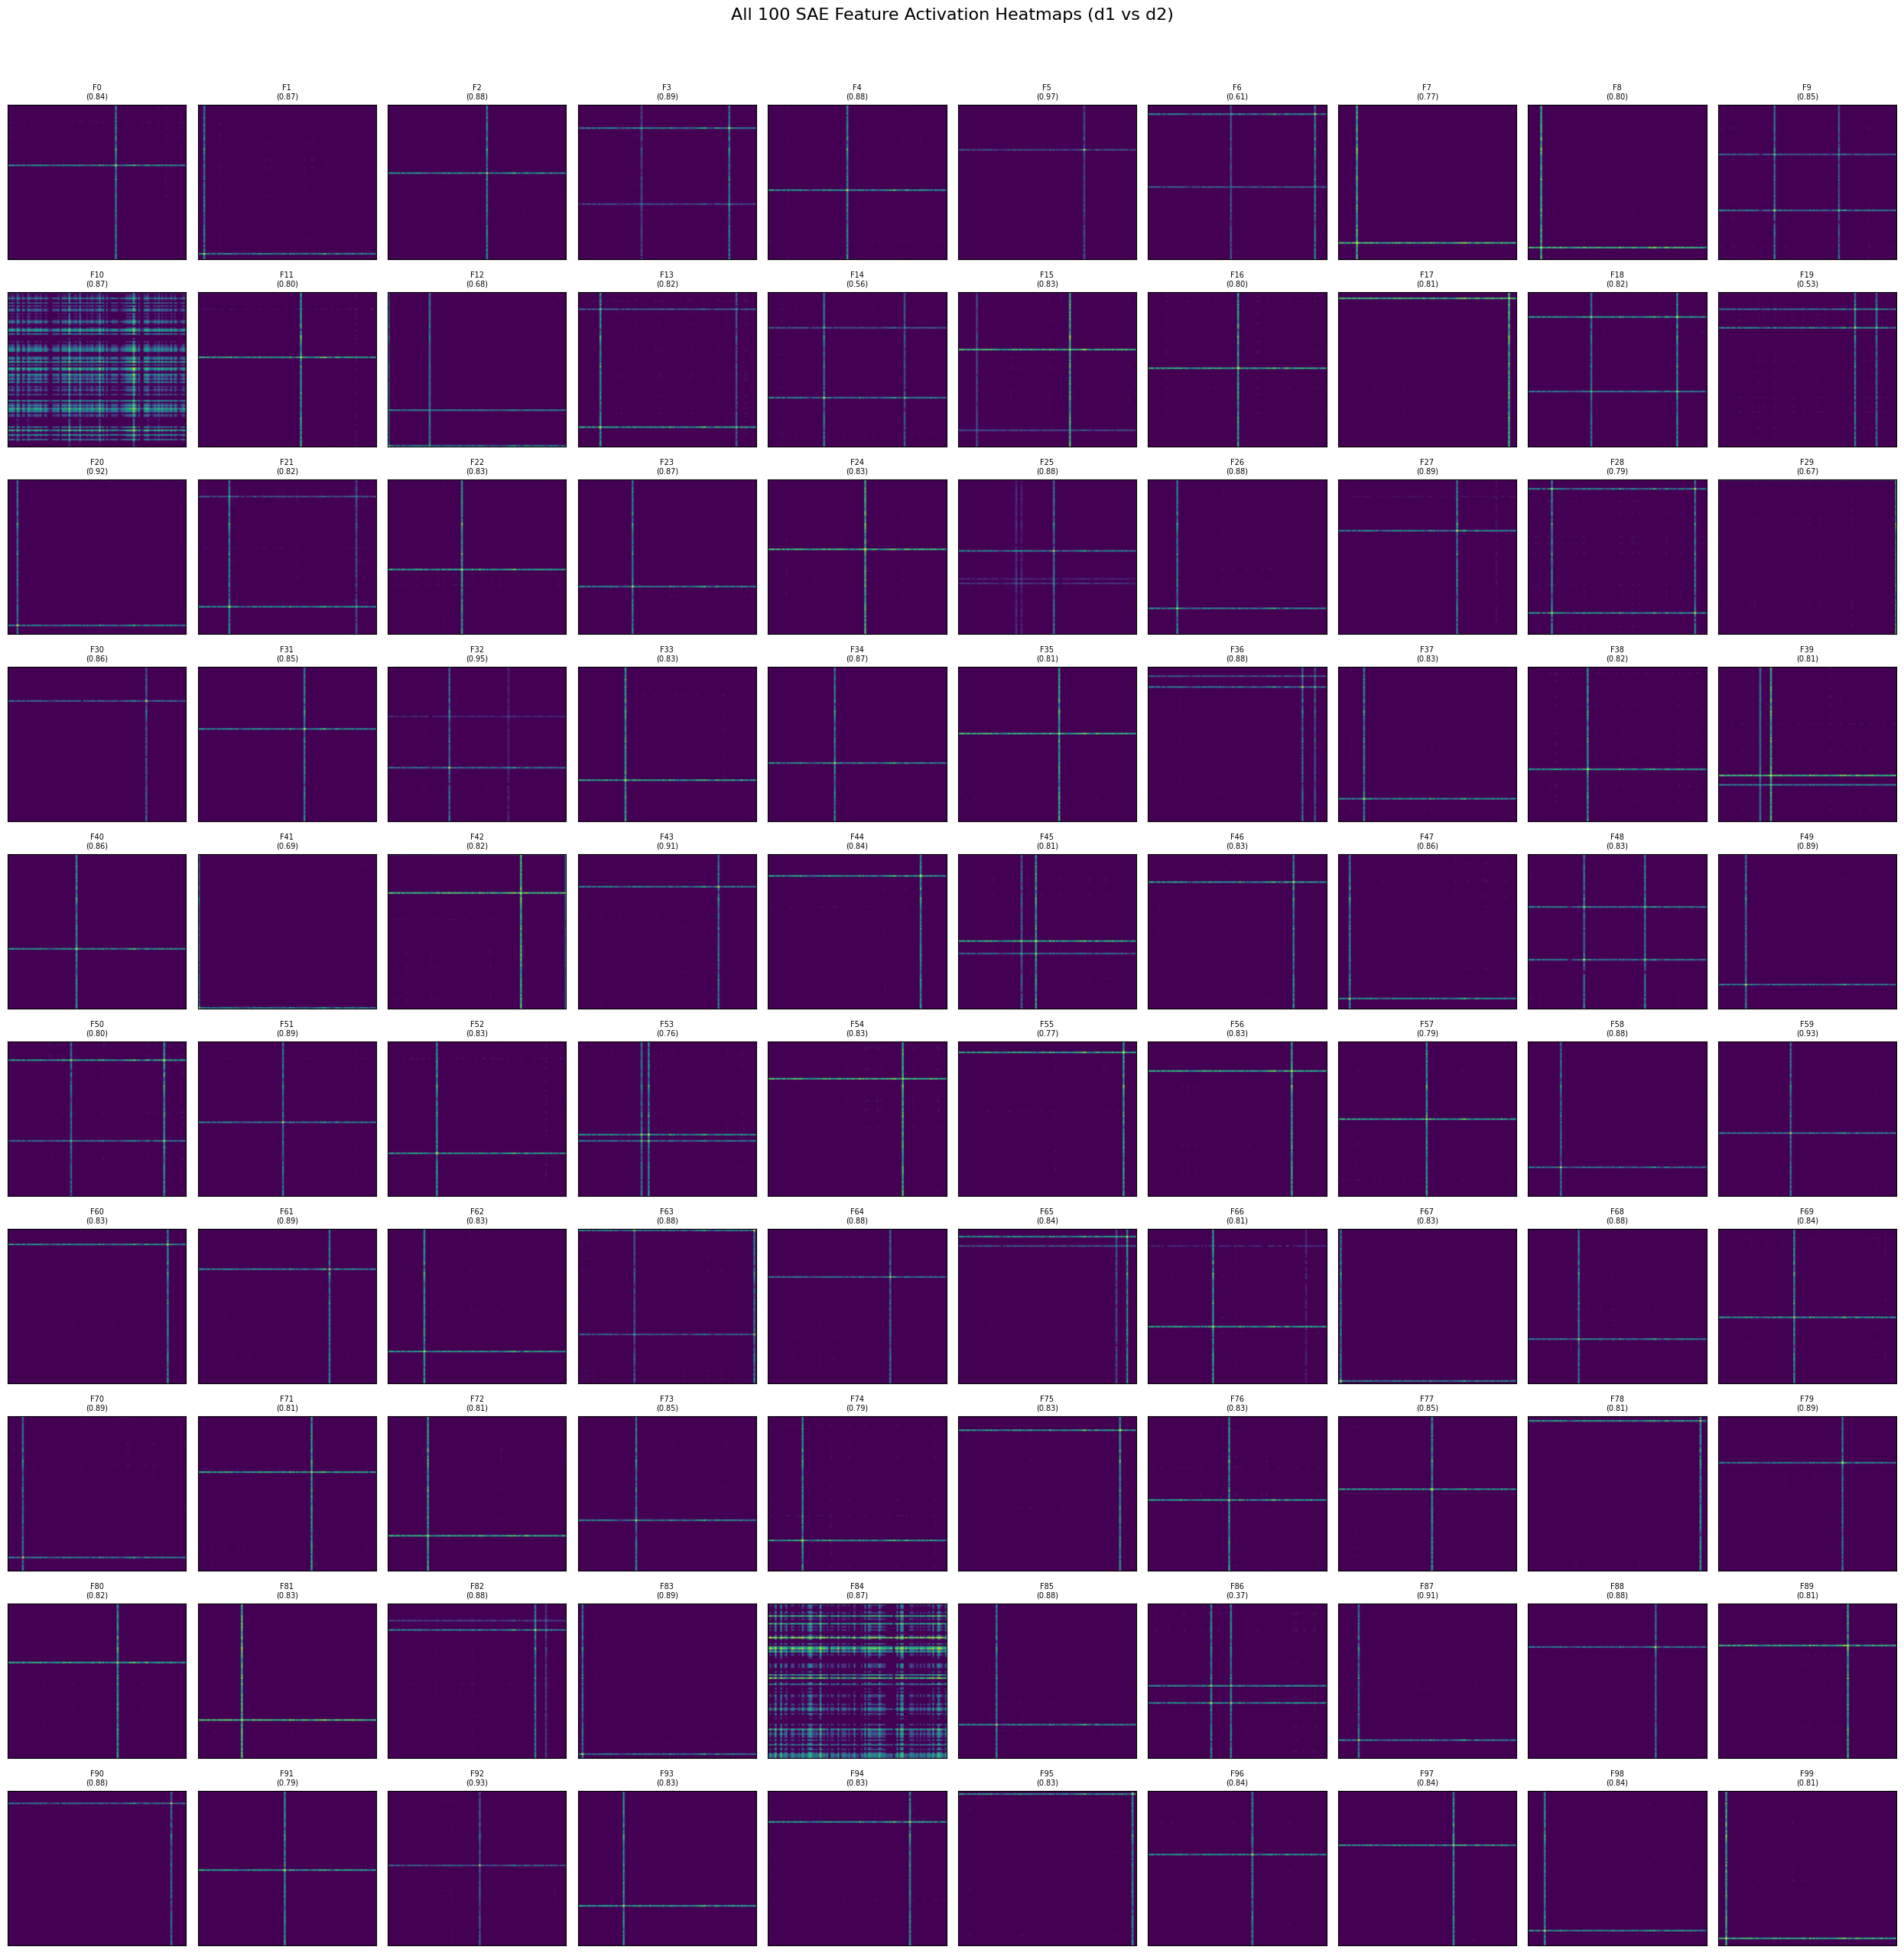

In [ ]:
# lets check the heatmap for all 100 features to compare

# Precompute all activation matrices
print("Computing activation matrices for all features...")
all_act_matrices = torch.zeros(D_SAE, N_DIGITS, N_DIGITS)
count_matrix = torch.zeros(N_DIGITS, N_DIGITS)

for i in range(n_samples):
    d1, d2 = d1_all[i].item(), d2_all[i].item()
    all_act_matrices[:, d1, d2] += sae_acts_all[i]
    count_matrix[d1, d2] += 1

all_act_matrices = all_act_matrices / count_matrix.clamp(min=1)

# Create 10x10 grid
fig, axes = plt.subplots(10, 10, figsize=(25, 25))
fig.suptitle('All 100 SAE Feature Activation Heatmaps (d1 vs d2)', fontsize=16, y=1.02)

for feat_idx in range(D_SAE):
    row, col = feat_idx // 10, feat_idx % 10
    ax = axes[row, col]
    
    im = ax.imshow(all_act_matrices[feat_idx].numpy(), cmap='viridis', origin='lower', aspect='auto')
    ax.set_title(f'F{feat_idx}\n({best_match[feat_idx]:.2f})', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
if SAVE_DIR:
    plt.savefig(f'{SAVE_DIR}/all_feature_heatmaps.png', dpi=150, bbox_inches='tight')
    print(f"Saved to {SAVE_DIR}/all_feature_heatmaps.png")
plt.show()

 huh - feature 86 activates when either 46 or 35 are present, and especially when they both are. several others are like this

 many other features (eg. 20, 90) seem to activate whenever a digit is present, eg. feature 90
 activates most for 91,91 and then the other activations are when either d1 or d2 are 91
 hence, could intuitively be a feature for 'is 91 present' --> but would have to do causal ablations to test this

 feature 10 and 84 however are heckin crazy looking ==> probs not as simple as encoding a digit
 they also correlate strongly with

Feature 10 vs Feature 84 — Activation Overlap

📊 Overlap Statistics (N = 10000):
  Both active:         0 (0.00%)
  Only F10:         4818 (48.18%)
  Only F84:         3709 (37.09%)
  Neither active:   1473 (14.73%)

🔗 Conditional Probabilities:
  P(F10 active) = 0.4818
  P(F84 active) = 0.3709
  P(F10 | F84)  = 0.0000  (vs 0.4818 baseline)
  P(F84 | F10)  = 0.0000  (vs 0.3709 baseline)

🎲 Independence Check:
  Expected if independent: 1787.0
  Actual co-activation:    0
  Ratio: 0.00x (anti-correlated)
  Activation magnitude correlation: r = -0.4696

🔍 When BOTH activate — what's special about these inputs?


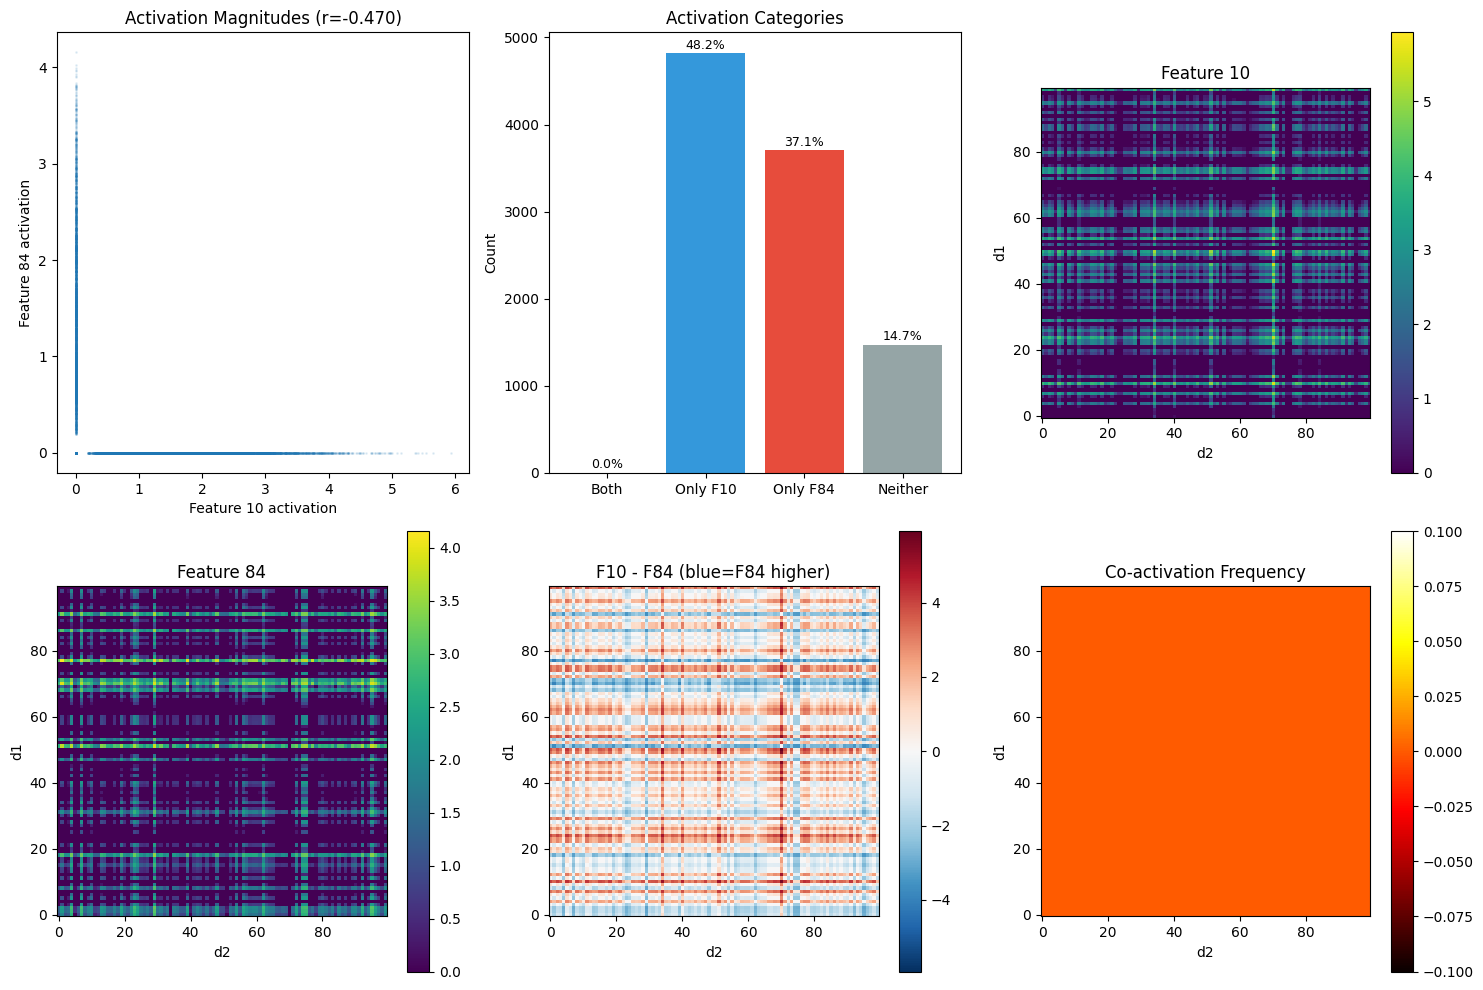


📈 Correlations with Attention Difference (α_d1 - α_d2):
  Feature 10: r = +0.8031
  Feature 84: r = -0.7169


In [ ]:
# compare features 10 and 84 

f10_acts = sae_acts_all[:, 10]
f84_acts = sae_acts_all[:, 84]

f10_active = f10_acts > 0
f84_active = f84_acts > 0

# Compute the 4 categories
both_active = (f10_active & f84_active).sum().item()
only_f10 = (f10_active & ~f84_active).sum().item()
only_f84 = (~f10_active & f84_active).sum().item()
neither = (~f10_active & ~f84_active).sum().item()

print("Feature 10 vs Feature 84 — Activation Overlap")
print("=" * 50)
print(f"\n📊 Overlap Statistics (N = {n_samples}):")
print(f"  Both active:     {both_active:>5} ({100*both_active/n_samples:.2f}%)")
print(f"  Only F10:        {only_f10:>5} ({100*only_f10/n_samples:.2f}%)")
print(f"  Only F84:        {only_f84:>5} ({100*only_f84/n_samples:.2f}%)")
print(f"  Neither active:  {neither:>5} ({100*neither/n_samples:.2f}%)")

# Conditional probabilities
p_f10 = f10_active.float().mean().item()
p_f84 = f84_active.float().mean().item()
p_f10_given_f84 = f10_active[f84_active].float().mean().item() if f84_active.sum() > 0 else 0
p_f84_given_f10 = f84_active[f10_active].float().mean().item() if f10_active.sum() > 0 else 0

print(f"\n🔗 Conditional Probabilities:")
print(f"  P(F10 active) = {p_f10:.4f}")
print(f"  P(F84 active) = {p_f84:.4f}")
print(f"  P(F10 | F84)  = {p_f10_given_f84:.4f}  (vs {p_f10:.4f} baseline)")
print(f"  P(F84 | F10)  = {p_f84_given_f10:.4f}  (vs {p_f84:.4f} baseline)")

# Are they independent? Compare P(both) to P(F10)*P(F84)
expected_both = p_f10 * p_f84 * n_samples
print(f"\n🎲 Independence Check:")
print(f"  Expected if independent: {expected_both:.1f}")
print(f"  Actual co-activation:    {both_active}")
print(f"  Ratio: {both_active/expected_both:.2f}x {'(correlated)' if both_active > expected_both else '(anti-correlated)'}")

# Correlation between activation magnitudes
corr_magnitude = np.corrcoef(f10_acts.numpy(), f84_acts.numpy())[0, 1]
print(f"  Activation magnitude correlation: r = {corr_magnitude:+.4f}")

# What inputs do they agree/disagree on?
print(f"\n🔍 When BOTH activate — what's special about these inputs?")
both_mask = f10_active & f84_active
if both_mask.sum() > 0:
    both_d1 = d1_all[both_mask]
    both_d2 = d2_all[both_mask]
    print(f"  Mean d1: {both_d1.float().mean():.1f}, Mean d2: {both_d2.float().mean():.1f}")
    print(f"  Mean |d1-d2|: {(both_d1 - both_d2).abs().float().mean():.1f}")
    print(f"  % where d1 > d2: {(both_d1 > both_d2).float().mean()*100:.1f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Scatter plot of activation magnitudes
axes[0, 0].scatter(f10_acts.numpy(), f84_acts.numpy(), alpha=0.1, s=1)
axes[0, 0].set_xlabel('Feature 10 activation')
axes[0, 0].set_ylabel('Feature 84 activation')
axes[0, 0].set_title(f'Activation Magnitudes (r={corr_magnitude:.3f})')

# Venn-style bar chart
categories = ['Both', 'Only F10', 'Only F84', 'Neither']
values = [both_active, only_f10, only_f84, neither]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
axes[0, 1].bar(categories, values, color=colors)
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Activation Categories')
for i, v in enumerate(values):
    axes[0, 1].text(i, v + 50, f'{100*v/n_samples:.1f}%', ha='center', fontsize=9)

# Side-by-side heatmaps
im1 = axes[0, 2].imshow(all_act_matrices[10].numpy(), cmap='viridis', origin='lower')
axes[0, 2].set_title('Feature 10')
axes[0, 2].set_xlabel('d2')
axes[0, 2].set_ylabel('d1')
plt.colorbar(im1, ax=axes[0, 2])

im2 = axes[1, 0].imshow(all_act_matrices[84].numpy(), cmap='viridis', origin='lower')
axes[1, 0].set_title('Feature 84')
axes[1, 0].set_xlabel('d2')
axes[1, 0].set_ylabel('d1')
plt.colorbar(im2, ax=axes[1, 0])

# Difference heatmap
diff_matrix = all_act_matrices[10] - all_act_matrices[84]
im3 = axes[1, 1].imshow(diff_matrix.numpy(), cmap='RdBu_r', origin='lower', 
                         vmin=-diff_matrix.abs().max(), vmax=diff_matrix.abs().max())
axes[1, 1].set_title('F10 - F84 (blue=F84 higher)')
axes[1, 1].set_xlabel('d2')
axes[1, 1].set_ylabel('d1')
plt.colorbar(im3, ax=axes[1, 1])

# Co-activation heatmap (where do BOTH fire?)
coact_matrix = torch.zeros(N_DIGITS, N_DIGITS)
for i in range(n_samples):
    if f10_active[i] and f84_active[i]:
        coact_matrix[d1_all[i], d2_all[i]] += 1
coact_matrix = coact_matrix / count_matrix.clamp(min=1)

im4 = axes[1, 2].imshow(coact_matrix.numpy(), cmap='hot', origin='lower')
axes[1, 2].set_title('Co-activation Frequency')
axes[1, 2].set_xlabel('d2')
axes[1, 2].set_ylabel('d1')
plt.colorbar(im4, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# Check correlations with order/attention
print(f"\n📈 Correlations with Attention Difference (α_d1 - α_d2):")
corr_f10_order = np.corrcoef(f10_acts.numpy(), alpha_diff.numpy())[0, 1]
corr_f84_order = np.corrcoef(f84_acts.numpy(), alpha_diff.numpy())[0, 1]
print(f"  Feature 10: r = {corr_f10_order:+.4f}")
print(f"  Feature 84: r = {corr_f84_order:+.4f}")

 they have 0 attn overlap! and they have strong opposite correlations with the attn difference

In [ ]:
print(f"\nF10 fires when α_d1 > α_d2: {(f10_active & (alpha_d1_all > alpha_d2_all)).sum() / f10_active.sum() * 100:.1f}%")
print(f"F84 fires when α_d1 < α_d2: {(f84_active & (alpha_d1_all < alpha_d2_all)).sum() / f84_active.sum() * 100:.1f}%")


F10 fires when α_d1 > α_d2: 89.5%
F84 fires when α_d1 < α_d2: 91.1%


 the features fire when the attention is higher for one digit than the other

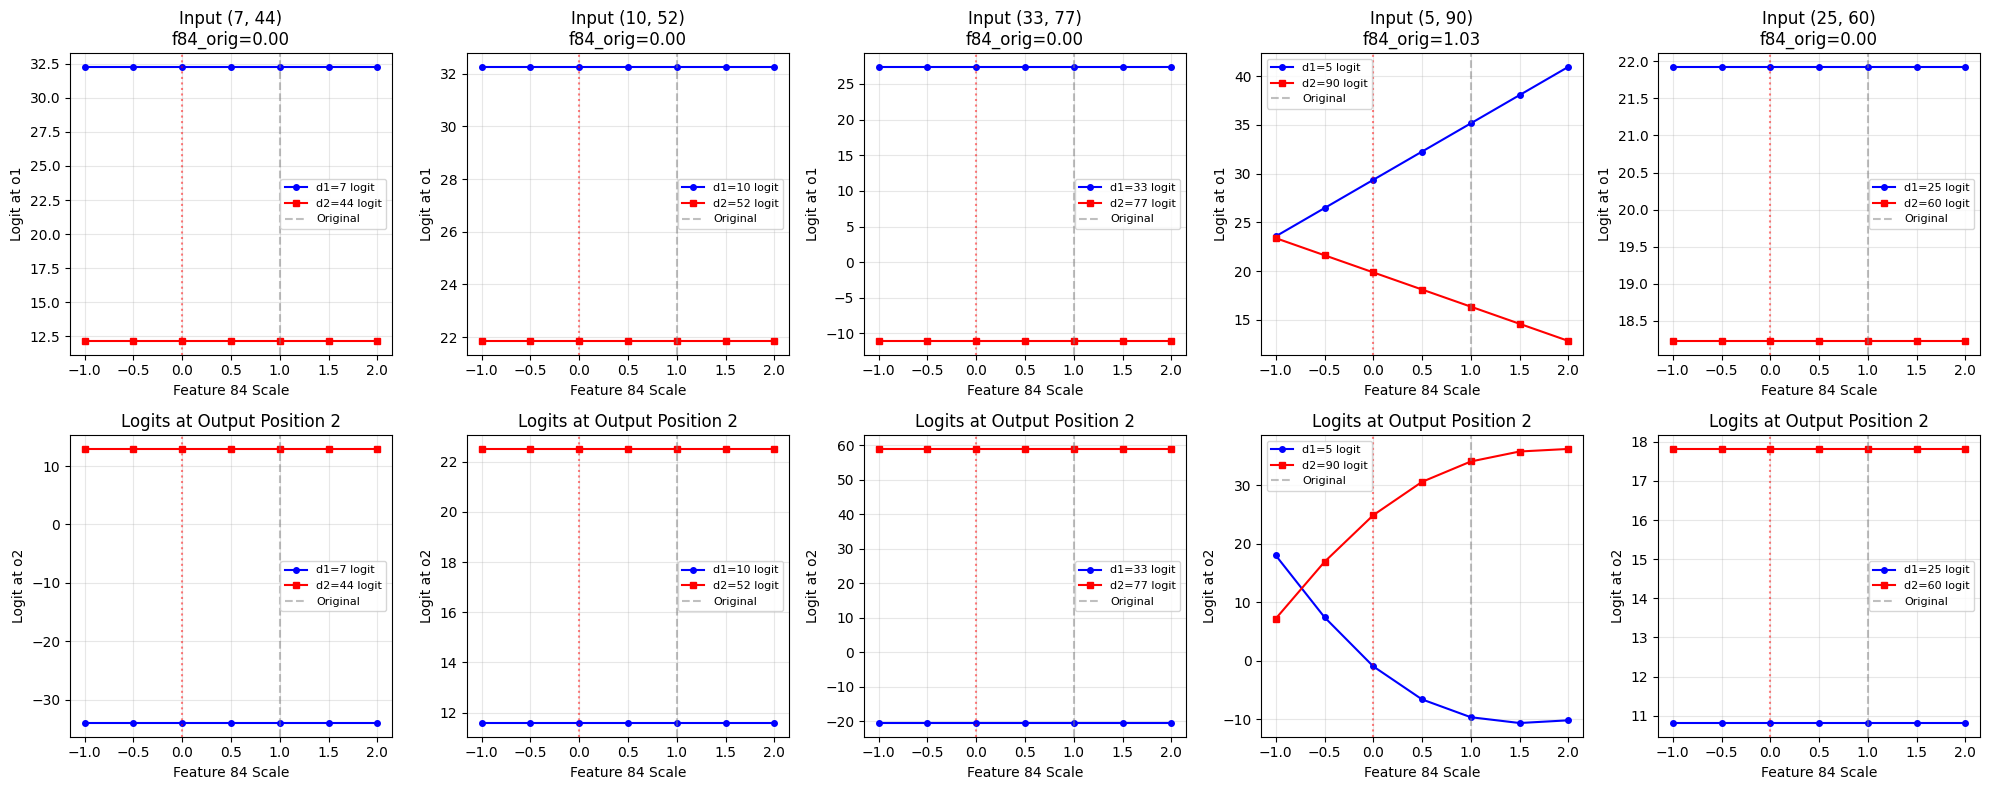

In [ ]:
# lets try some steering on random pairs for 10 and 84
ORDER_FEATURE_IDX = 84

# Select diverse test cases (different digit pairs)
test_pairs = [(7, 44), (10, 52), (33, 77), (5, 90), (25, 60)]

# Extended scale range: -1 to 2 to test negative scaling (reversing the feature)
scale_factors = np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])

# Storage for plotting
all_results = []

for d1_val, d2_val in test_pairs:
    # Find this pair in dataset
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    if mask.sum() == 0:
        continue
    idx = torch.where(mask)[0][0].item()
    
    inputs_i = val_ds.tensors[0][idx:idx+1].to(device)
    z_orig = sae_acts_all[idx].clone().to(device)
    order_feat_orig = z_orig[ORDER_FEATURE_IDX].item()
    
    logit_d1_at_o1 = []
    logit_d2_at_o1 = []
    logit_d1_at_o2 = []
    logit_d2_at_o2 = []
    output_o1 = []
    output_o2 = []
    
    for scale in scale_factors:
        z_scaled = z_orig.clone()
        z_scaled[ORDER_FEATURE_IDX] = order_feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1)
        logits_o1 = patched_logits[0, -2, :N_DIGITS]
        logits_o2 = patched_logits[0, -1, :N_DIGITS]
        
        logit_d1_at_o1.append(logits_o1[d1_val].item())
        logit_d2_at_o1.append(logits_o1[d2_val].item())
        logit_d1_at_o2.append(logits_o2[d1_val].item())
        logit_d2_at_o2.append(logits_o2[d2_val].item())
        output_o1.append(logits_o1.argmax().item())
        output_o2.append(logits_o2.argmax().item())
    
    all_results.append({
        'd1': d1_val, 'd2': d2_val,
        'scales': scale_factors,
        'logit_d1_o1': logit_d1_at_o1,
        'logit_d2_o1': logit_d2_at_o1,
        'logit_d1_o2': logit_d1_at_o2,
        'logit_d2_o2': logit_d2_at_o2,
        'output_o1': output_o1,
        'output_o2': output_o2,
        'order_feat_orig': order_feat_orig,
    })

# Plot results
fig, axes = plt.subplots(2, len(all_results), figsize=(4*len(all_results), 8), squeeze=False)

for col, result in enumerate(all_results):
    d1, d2 = result['d1'], result['d2']
    scales = result['scales']
    
    # Top row: Logits at o1 position
    ax1 = axes[0, col]
    ax1.plot(scales, result['logit_d1_o1'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax1.plot(scales, result['logit_d2_o1'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_xlabel(f'Feature {ORDER_FEATURE_IDX} Scale')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'Input ({d1}, {d2})\nf{ORDER_FEATURE_IDX}_orig={result["order_feat_orig"]:.2f}')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Bottom row: Logits at o2 position
    ax2 = axes[1, col]
    ax2.plot(scales, result['logit_d1_o2'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax2.plot(scales, result['logit_d2_o2'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax2.set_xlabel(f'Feature {ORDER_FEATURE_IDX} Scale')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'Logits at Output Position 2')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_DIR: plt.savefig(os.path.join(SAVE_DIR, f'feature_{ORDER_FEATURE_IDX}_logit_steering.png'), dpi=150, bbox_inches='tight')
plt.show()

 what is the output of (7,4) when we set f10 activation to 0 and reconstruct?

In [ ]:
# Test (7, 4) with F10 ablated
feat_idx = 10
feat_mult = -1.0 # when lines cross in above figure

d1_val, d2_val = 7, 4
mask = (d1_all == d1_val) & (d2_all == d2_val)
idx = torch.where(mask)[0][0].item()

inputs_i = val_ds.tensors[0][idx:idx+1].to(device)
z_orig = sae_acts_all[idx].clone().to(device)

print(f"Input: ({d1_val}, {d2_val})")
print(f"Original F10 activation: {z_orig[10]:.3f}")
print(f"Original F84 activation: {z_orig[84]:.3f}")

# Original output
with torch.no_grad():
    orig_logits = model(inputs_i)
    orig_o1 = orig_logits[0, -2, :N_DIGITS].argmax().item()
    orig_o2 = orig_logits[0, -1, :N_DIGITS].argmax().item()
print(f"Original output: ({orig_o1}, {orig_o2})")

# Ablate F10
z_ablated = z_orig.clone()
z_ablated[feat_idx] = feat_mult* z_ablated[feat_idx]
recon = sae.decode(z_ablated.unsqueeze(0))

with torch.no_grad():
    patched_logits = model.run_with_hooks(
        inputs_i,
        fwd_hooks=[(hook_name_resid, make_sae_patch_hook(recon, SEP_TOKEN_INDEX))]
    )
    ablated_o1 = patched_logits[0, -2, :N_DIGITS].argmax().item()
    ablated_o2 = patched_logits[0, -1, :N_DIGITS].argmax().item()

print(f"After F10 ablation: ({ablated_o1}, {ablated_o2})")

Input: (7, 4)
Original F10 activation: 1.051
Original F84 activation: 0.000
Original output: (7, 7)
After F10 ablation: (4, 7)


In [ ]:
# for eg. (10,52) input, we set f10 act to 0 and get reversed output (52,10) - original was 10,52 correctly
# but for eg. 7,4 - we set f10 to -1 and get (4,7) (swapped) BUT original output was (7,7) - incorrect!

In [ ]:
# sort all 100^2 activations into 3 lists: 
# 1) f10 active
# 2) f84 active
# 3) neither active
# we know there's no overlap so this should work 

In [ ]:
# Sort all activations into 3 categories

f10_active = sae_acts_all[:, 10] > 0
f84_active = sae_acts_all[:, 84] > 0

# Get indices for each category
idx_f10 = torch.where(f10_active)[0]
idx_f84 = torch.where(f84_active)[0]
idx_neither = torch.where(~f10_active & ~f84_active)[0]

print(f"F10 active: {len(idx_f10)} samples ({100*len(idx_f10)/n_samples:.1f}%)")
print(f"F84 active: {len(idx_f84)} samples ({100*len(idx_f84)/n_samples:.1f}%)")
print(f"Neither:    {len(idx_neither)} samples ({100*len(idx_neither)/n_samples:.1f}%)")

# Verify no overlap
assert (f10_active & f84_active).sum() == 0, "Unexpected overlap!"
assert len(idx_f10) + len(idx_f84) + len(idx_neither) == n_samples, "Missing samples!"
print("\n✓ No overlap, all samples accounted for")


# For each category, compute model accuracy
def compute_accuracy(indices):
    if len(indices) == 0:
        return 0.0, 0, 0
    
    correct = 0
    for idx in indices:
        inputs_i = val_ds.tensors[0][idx:idx+1].to(device)
        with torch.no_grad():
            logits = model(inputs_i)
            pred_o1 = logits[0, -2, :N_DIGITS].argmax().item()
            pred_o2 = logits[0, -1, :N_DIGITS].argmax().item()
        
        d1, d2 = d1_all[idx].item(), d2_all[idx].item()
        if pred_o1 == d1 and pred_o2 == d2:
            correct += 1
    
    return correct / len(indices), correct, len(indices)

print("\nComputing accuracy for each category...")
acc_f10, corr_f10, tot_f10 = compute_accuracy(idx_f10)
acc_f84, corr_f84, tot_f84 = compute_accuracy(idx_f84)
acc_neither, corr_neither, tot_neither = compute_accuracy(idx_neither)

print(f"\n{'Category':<15} {'Accuracy':<12} {'Correct':<12} {'Total':<10}")
print("-" * 50)
print(f"F10 active      {acc_f10*100:>6.1f}%      {corr_f10:<12} {tot_f10:<10}")
print(f"F84 active      {acc_f84*100:>6.1f}%      {corr_f84:<12} {tot_f84:<10}")
print(f"Neither         {acc_neither*100:>6.1f}%      {corr_neither:<12} {tot_neither:<10}")

print(f"\nOverall: {(corr_f10+corr_f84+corr_neither)/n_samples*100:.1f}%")

F10 active: 4818 samples (48.2%)
F84 active: 3709 samples (37.1%)
Neither:    1473 samples (14.7%)

✓ No overlap, all samples accounted for

Computing accuracy for each category...

Category        Accuracy     Correct      Total     
--------------------------------------------------
F10 active        91.0%      4383         4818      
F84 active        94.6%      3508         3709      
Neither           83.3%      1227         1473      

Overall: 91.2%


In [ ]:
# Get list input pairs for each category

pairs_f10 = list(zip(d1_all[idx_f10].tolist(), d2_all[idx_f10].tolist()))
pairs_f84 = list(zip(d1_all[idx_f84].tolist(), d2_all[idx_f84].tolist()))
pairs_neither = list(zip(d1_all[idx_neither].tolist(), d2_all[idx_neither].tolist()))

# print(f"F10 active pairs: {len(pairs_f10)}")
# print(f"F84 active pairs: {len(pairs_f84)}")
# print(f"Neither active pairs: {len(pairs_neither)}")

# Get unique pairs (in case of duplicates in dataset - this shouldn't happen though)
unique_f10 = set(pairs_f10)
unique_f84 = set(pairs_f84)
unique_neither = set(pairs_neither)

print(f"\nUnique pairs:")
print(f"  F10: {len(unique_f10)}")
print(f"  F84: {len(unique_f84)}")
print(f"  Neither: {len(unique_neither)}")

# Show sample of "neither" pairs - these are the interesting edge cases
print(f"\nSample 'neither' pairs (first 20):")
print(pairs_neither[:20])


Unique pairs:
  F10: 4818
  F84: 3709
  Neither: 1473

Sample 'neither' pairs (first 20):
[(17, 12), (11, 55), (55, 79), (31, 40), (9, 94), (76, 79), (34, 15), (40, 12), (76, 43), (6, 94), (98, 93), (97, 79), (59, 0), (38, 39), (58, 93), (96, 25), (85, 65), (13, 0), (21, 66), (84, 49)]


In [ ]:
# Summary of digits in each category

def analyze_digits(pairs, name):
    """Analyze which digits appear in a list of (d1, d2) pairs."""
    d1_digits = set(p[0] for p in pairs)
    d2_digits = set(p[1] for p in pairs)
    all_digits = d1_digits | d2_digits
    
    print(f"\n{'='*50}")
    print(f"{name} ({len(pairs)} pairs)")
    print(f"{'='*50}")
    print(f"  Digits in d1 position: {len(d1_digits)} unique")
    print(f"  Digits in d2 position: {len(d2_digits)} unique")
    print(f"  Digits in either:      {len(all_digits)} unique")
    
    # If small enough, show the actual digits
    if len(all_digits) <= 30:
        print(f"\n  All digits: {sorted(all_digits)}")
        print(f"  d1 only: {sorted(d1_digits - d2_digits)}")
        print(f"  d2 only: {sorted(d2_digits - d1_digits)}")
        print(f"  Both positions: {sorted(d1_digits & d2_digits)}")
    
    return d1_digits, d2_digits, all_digits

d1_f10, d2_f10, all_f10 = analyze_digits(pairs_f10, "F10 Active (d1 > d2 attention)")
d1_f84, d2_f84, all_f84 = analyze_digits(pairs_f84, "F84 Active (d2 > d1 attention)")
d1_neither, d2_neither, all_neither = analyze_digits(pairs_neither, "Neither Active (ambiguous)")

# Cross-list comparison
print(f"\n{'='*50}")
print("CROSS-LIST DIGIT OVERLAP")
print(f"{'='*50}")

print(f"\nDigits appearing in ALL lists:")
common_all = all_f10 & all_f84 & all_neither
print(f"  {len(common_all)} digits: {sorted(common_all) if len(common_all) <= 20 else '(too many to show)'}")

print(f"\nDigits ONLY in F10 pairs:")
only_f10 = all_f10 - all_f84 - all_neither
print(f"  {len(only_f10)} digits: {sorted(only_f10)}")

print(f"\nDigits ONLY in F84 pairs:")
only_f84 = all_f84 - all_f10 - all_neither
print(f"  {len(only_f84)} digits: {sorted(only_f84)}")

print(f"\nDigits ONLY in 'neither' pairs:")
only_neither = all_neither - all_f10 - all_f84
print(f"  {len(only_neither)} digits: {sorted(only_neither)}")

# Summary table
print(f"\n{'='*50}")
print("SUMMARY TABLE")
print(f"{'='*50}")
print(f"{'Category':<20} {'d1 digits':<12} {'d2 digits':<12} {'Either':<12}")
print("-" * 56)
print(f"{'F10 Active':<20} {len(d1_f10):<12} {len(d2_f10):<12} {len(all_f10):<12}")
print(f"{'F84 Active':<20} {len(d1_f84):<12} {len(d2_f84):<12} {len(all_f84):<12}")
print(f"{'Neither':<20} {len(d1_neither):<12} {len(d2_neither):<12} {len(all_neither):<12}")


F10 Active (d1 > d2 attention) (4818 pairs)
  Digits in d1 position: 94 unique
  Digits in d2 position: 100 unique
  Digits in either:      100 unique

F84 Active (d2 > d1 attention) (3709 pairs)
  Digits in d1 position: 84 unique
  Digits in d2 position: 100 unique
  Digits in either:      100 unique

Neither Active (ambiguous) (1473 pairs)
  Digits in d1 position: 86 unique
  Digits in d2 position: 98 unique
  Digits in either:      100 unique

CROSS-LIST DIGIT OVERLAP

Digits appearing in ALL lists:
  100 digits: (too many to show)

Digits ONLY in F10 pairs:
  0 digits: []

Digits ONLY in F84 pairs:
  0 digits: []

Digits ONLY in 'neither' pairs:
  0 digits: []

SUMMARY TABLE
Category             d1 digits    d2 digits    Either      
--------------------------------------------------------
F10 Active           94           100          100         
F84 Active           84           100          100         
Neither              86           98           100         


 all digits appear in all 3 lists

In [ ]:
# What determines "neither"? Check attention magnitudes

for name, idx_set in [("F10", idx_f10), ("F84", idx_f84), ("Neither", idx_neither)]:
    ad1 = alpha_d1_all[idx_set]
    ad2 = alpha_d2_all[idx_set]
    diff = (ad1 - ad2).abs()
    
    print(f"{name}:")
    print(f"  Mean α_d1: {ad1.mean():.3f}, Mean α_d2: {ad2.mean():.3f}")
    print(f"  Mean |α_d1 - α_d2|: {diff.mean():.3f}")
    print(f"  Min |α_d1 - α_d2|:  {diff.min():.3f}")
    print()

F10:
  Mean α_d1: 0.616, Mean α_d2: 0.384
  Mean |α_d1 - α_d2|: 0.248
  Min |α_d1 - α_d2|:  0.000

F84:
  Mean α_d1: 0.382, Mean α_d2: 0.618
  Mean |α_d1 - α_d2|: 0.248
  Min |α_d1 - α_d2|:  0.000

Neither:
  Mean α_d1: 0.498, Mean α_d2: 0.502
  Mean |α_d1 - α_d2|: 0.112
  Min |α_d1 - α_d2|:  0.000



 for neither, the mean attn for d1 and d2 is about 50/50! as shown in the paper
 for f10, mean a_d1 > mean a_d2 and opposite for f84
 but - errors aren't explained by this...:
 ```
 Category        Accuracy     Correct      Total
 --------------------------------------------------
 F10 active        91.0%      4383         4818
 F84 active        94.6%      3508         3709

In [ ]:
# TODO next:
# explore errors more --> what causes them? maybe attention doesnt actually matter? look back at paper
# look again at digits in each list - the digit quantity is irrelevant, but does eg. 91 in d1 only appear in one list?
# look again at nb_190126 - where the other graphs after 3c any good?
# what am i trying to achieve --> is this helping with the main goal?